# Introduction to Classification in Machine Learning

This notebook covers the fundamentals of classification:

1. **Supervised Learning Framework** - Definitions and concepts
2. **Data: The MNIST Dataset** - Loading and exploring the data
3. **Data Preprocessing** - Subset selection, normalization, train-test split, dimensionality reduction
4. **Evaluation Metrics** - Confusion matrix, accuracy, precision, recall, F1-score
5. **Classification Algorithms** - K-NN, Naive Bayes, Logistic Regression, Decision Trees, Random Forest, SVM
6. **Model Comparison** - Performance summary and algorithm selection guidelines
7. **Feature Importance Analysis** - Understanding which features drive predictions
8. **Summary** - Key takeaways and what's next

---

In [39]:
# Required imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import time
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# Plot settings
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = [10, 6]

print("All imports successful!")

All imports successful!


---
# 1. Supervised Learning Framework

## Definition (Supervised Learning)

Given a training set $\mathcal{D} = \{(\mathbf{x}_1, y_1), (\mathbf{x}_2, y_2), \ldots, (\mathbf{x}_n, y_n)\}$ where:
- $\mathbf{x}_i \in \mathbb{R}^d$ is a **feature vector** (input)
- $y_i \in \mathcal{Y}$ is the corresponding **label** (output)

The goal is to learn a function $f: \mathbb{R}^d \rightarrow \mathcal{Y}$ that maps inputs to outputs.

**In short:** Given input-output examples, learn a function that predicts outputs for new inputs.

## Definition (Classification)

**Classification** is supervised learning where $\mathcal{Y}$ is a finite discrete set:
$$\mathcal{Y} = \{c_1, c_2, \ldots, c_K\}$$

Each $c_k$ is called a **class** or **category**.

**In short:** Assign each input to one of several predefined categories.

**Intuition:** Think of sorting mail into boxes. Each letter (data point) has features (size, weight, address format) and belongs to a category (personal, business, spam). We learn the sorting rules from examples.

## Definition (Hypothesis Space)

The set of all possible functions $\mathcal{H}$ that our algorithm can learn is called the **hypothesis space**. Different algorithms define different hypothesis spaces:
- Linear classifiers: $\mathcal{H} = \{f(\mathbf{x}) = \text{sign}(\mathbf{w}^T\mathbf{x} + b)\}$
- Decision trees: $\mathcal{H} = \{\text{piecewise constant functions}\}$

---
# 2. Data: The MNIST Dataset

## Dataset Description

MNIST consists of $28 \times 28$ grayscale images of handwritten digits (0-9).

Each image can be represented as:
- A matrix $\mathbf{X} \in \mathbb{R}^{28 \times 28}$ where $X_{ij} \in [0, 255]$ represents pixel intensity
- Or equivalently, a flattened vector $\mathbf{x} \in \mathbb{R}^{784}$

In [40]:
# Load MNIST dataset
print("Loading MNIST dataset...")
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X_full = mnist.data
y_full = mnist.target.astype(int)
print(f"Dataset loaded: {X_full.shape[0]} samples, {X_full.shape[1]} features")

Loading MNIST dataset...
Dataset loaded: 70000 samples, 784 features


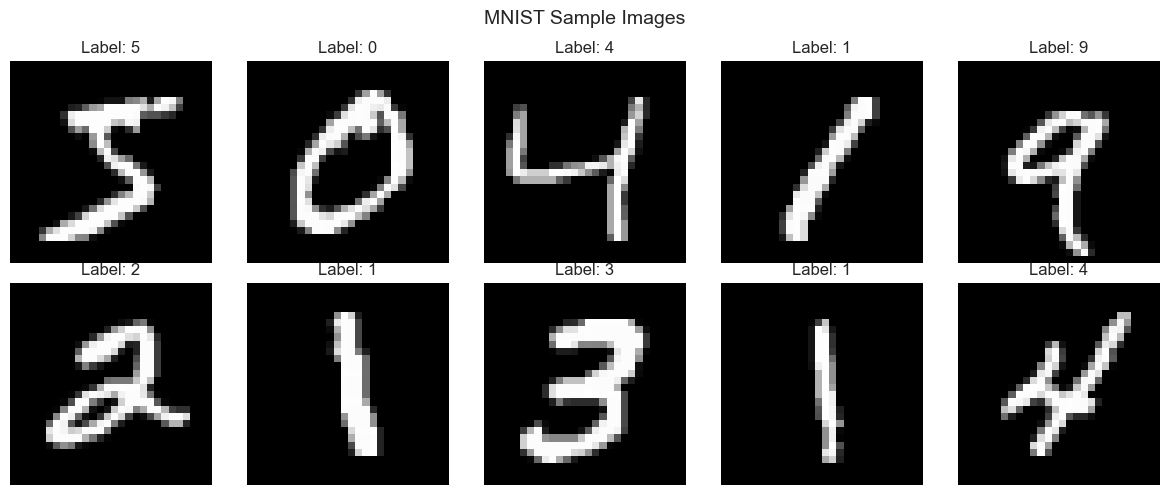

In [41]:
# Visualize sample images
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_full[i].reshape(28, 28), cmap='gray')
    ax.set_title(f'Label: {y_full[i]}', fontsize=12)
    ax.axis('off')
plt.suptitle('MNIST Sample Images', fontsize=14)
plt.tight_layout()
plt.show()

### Alternate Method: Loading from Local Files

If you have MNIST downloaded locally in IDX format:

In [42]:
# Example: Reading MNIST from local IDX files (reference only)
import struct
import gzip

def read_idx_images(filename):
    """Read MNIST images from IDX file format."""
    with gzip.open(filename, 'rb') as f:
        magic, num, rows, cols = struct.unpack('>IIII', f.read(16))
        images = np.frombuffer(f.read(), dtype=np.uint8)
        return images.reshape(num, rows * cols)

def read_idx_labels(filename):
    """Read MNIST labels from IDX file format."""
    with gzip.open(filename, 'rb') as f:
        magic, num = struct.unpack('>II', f.read(8))
        return np.frombuffer(f.read(), dtype=np.uint8)

# Usage: X = read_idx_images('train-images-idx3-ubyte.gz')
print("Local file readers defined (for reference)")

Local file readers defined (for reference)


---
# 3. Data Preprocessing

## 3.1 Subset Selection

We select 5 visually similar digits: $\mathcal{Y} = \{3, 5, 6, 8, 9\}$

In [43]:
# Select digits and sample
selected_digits = [3, 5, 6, 8, 9]
samples_per_class = 1000

# Filter and sample
X_list, y_list = [], []
for digit in selected_digits:
    mask = y_full == digit
    indices = np.random.choice(np.where(mask)[0], samples_per_class, replace=False)
    X_list.append(X_full[indices])
    y_list.append(y_full[indices])

X = np.vstack(X_list)
y = np.hstack(y_list)

print(f"Selected dataset: {X.shape[0]} samples")
print(f"Classes: {selected_digits}")
print(f"Samples per class: {samples_per_class}")

Selected dataset: 5000 samples
Classes: [3, 5, 6, 8, 9]
Samples per class: 1000


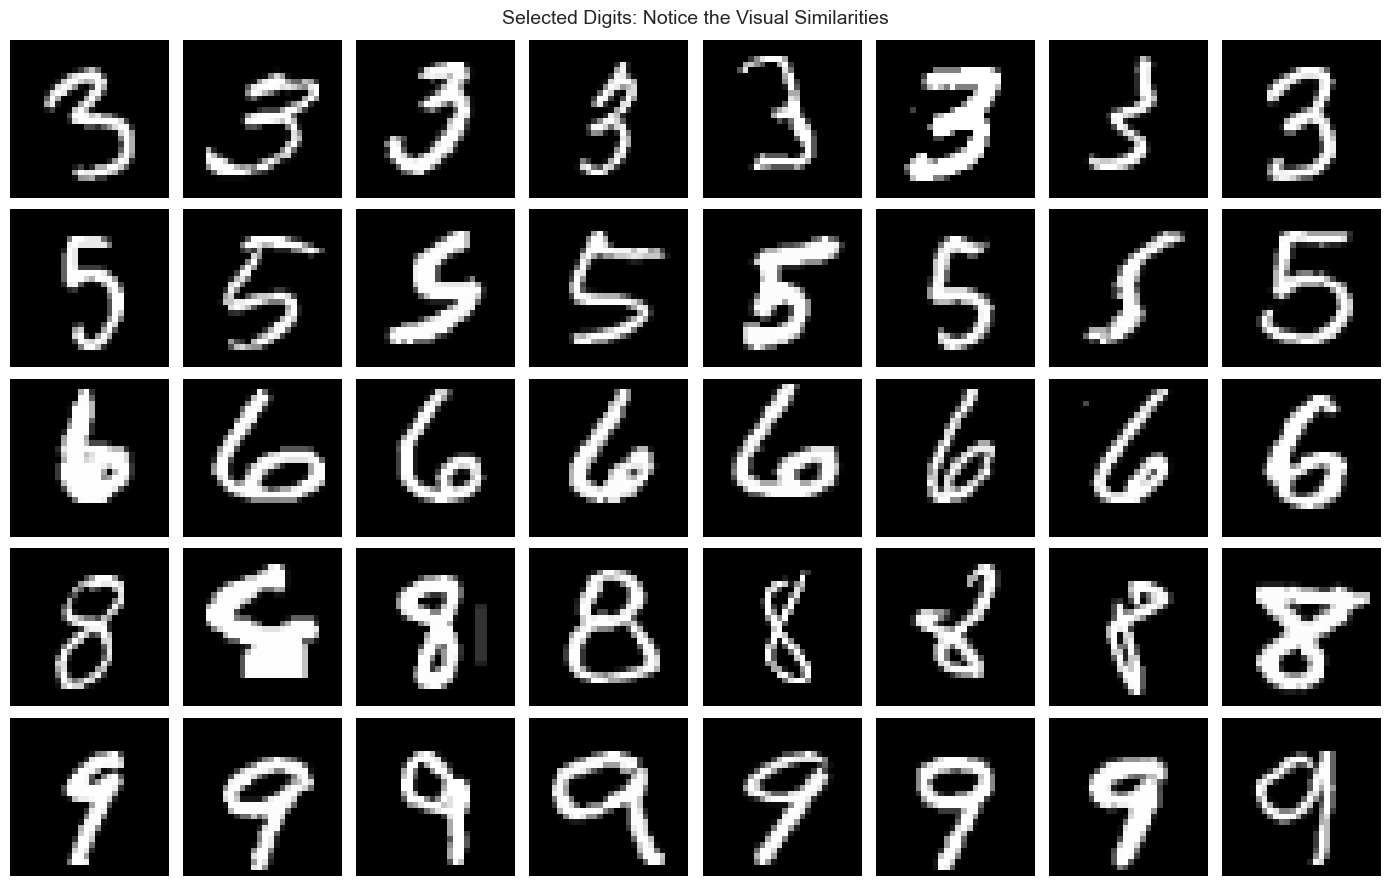

In [44]:
# Visualize selected digits side by side
fig, axes = plt.subplots(5, 8, figsize=(14, 9))
for row, digit in enumerate(selected_digits):
    digit_images = X[y == digit][:8]
    for col, img in enumerate(digit_images):
        axes[row, col].imshow(img.reshape(28, 28), cmap='gray')
        axes[row, col].axis('off')
    axes[row, 0].set_ylabel(f'Digit {digit}', fontsize=12, rotation=0, labelpad=30)

plt.suptitle('Selected Digits: Notice the Visual Similarities', fontsize=14)
plt.tight_layout()
plt.show()

## 3.2 Feature Normalization

### Definition (Min-Max Normalization)

For a feature $x$ with range $[x_{min}, x_{max}]$, the normalized value is:
$$\tilde{x} = \frac{x - x_{min}}{x_{max} - x_{min}}$$

For pixel values: $x \in [0, 255] \rightarrow \tilde{x} \in [0, 1]$

**In short:** Scale all feature values to a common range (typically 0 to 1).

**Why normalize?**
1. Many algorithms (SVM, K-NN) use distance metrics sensitive to feature scales
2. Gradient-based optimization converges faster with normalized features
3. Prevents features with large ranges from dominating

In [45]:
# Normalize pixel values to [0, 1]
print(f"Before normalization: [{X.min()}, {X.max()}]")
X_normalized = X / 255.0
print(f"After normalization: [{X_normalized.min():.1f}, {X_normalized.max():.1f}]")

Before normalization: [0, 255]
After normalization: [0.0, 1.0]


## 3.3 Train-Test Split

### Definition (Generalization)

The **generalization error** is the expected error on unseen data:
$$R(f) = \mathbb{E}_{(\mathbf{x}, y) \sim P}[\mathcal{L}(f(\mathbf{x}), y)]$$

where $P$ is the true data distribution and $\mathcal{L}$ is the loss function.

**In short:** How well does the model perform on data it has never seen before?

### Definition (Train-Test Split)

We partition $\mathcal{D}$ into:
- **Training set** $\mathcal{D}_{train}$: Used to learn $f$
- **Test set** $\mathcal{D}_{test}$: Used to estimate $R(f)$

$$\mathcal{D} = \mathcal{D}_{train} \cup \mathcal{D}_{test}, \quad \mathcal{D}_{train} \cap \mathcal{D}_{test} = \emptyset$$

**In short:** Hold out some data for testing so we can honestly evaluate the model.

**Intuition:** Training is like studying from a textbook; testing is like the final exam on new questions.

In [46]:
# Split data: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X_normalized, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

Training set: 4000 samples
Test set: 1000 samples


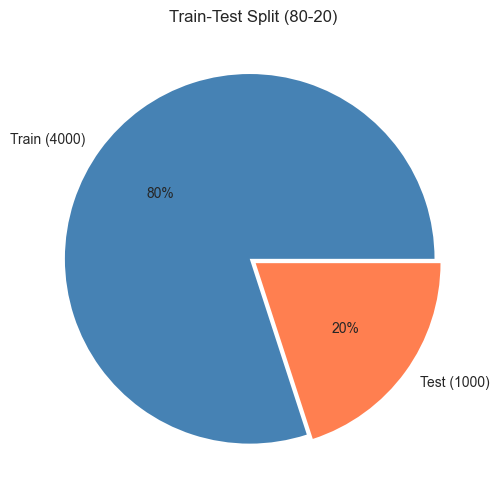

In [47]:
# Visualize split
fig, ax = plt.subplots(figsize=(8, 6))
sizes = [len(X_train), len(X_test)]
ax.pie(sizes, labels=[f'Train ({sizes[0]})', f'Test ({sizes[1]})'], 
       autopct='%1.0f%%', colors=['steelblue', 'coral'], explode=(0.02, 0.02))
ax.set_title('Train-Test Split (80-20)')
plt.show()

## 3.4 Dimensionality Reduction for Visualization
Our images have 784 features (pixels), making direct visualization impossible. Dimensionality reduction projects this high-dimensional data to 2D while preserving key structure. This helps us visually assess class separability, if digits overlap heavily in 2D, classification will be harder; if they form distinct clusters, simpler algorithms may work well.

### Definition (PCA)

**Principal Component Analysis** finds orthogonal directions of maximum variance.

Given centered data matrix $\mathbf{X} \in \mathbb{R}^{n \times d}$, PCA computes:
$$\mathbf{X} = \mathbf{U} \mathbf{\Sigma} \mathbf{V}^T$$

The first $k$ principal components are columns of $\mathbf{V}_k$, and the projection is:
$$\mathbf{Z} = \mathbf{X} \mathbf{V}_k \in \mathbb{R}^{n \times k}$$

For visualization, we use $k=2$.

**In short:** Project high-dimensional data onto the directions where it varies most.

In [48]:
from sklearn.decomposition import PCA

# Reduce to 2D for visualization
pca = PCA(n_components=2)
X_train_2d = pca.fit_transform(X_train)

print(f"Variance explained by 2 components: {pca.explained_variance_ratio_.sum()*100:.1f}%")

Variance explained by 2 components: 17.1%


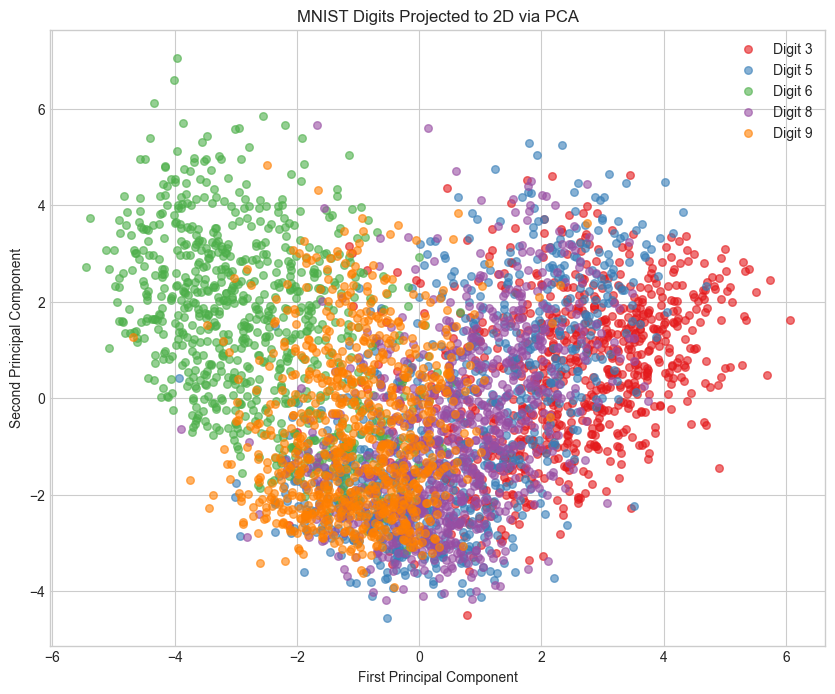

In [49]:
# 2D scatter plot
plt.figure(figsize=(10, 8))
colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00']
for i, digit in enumerate(selected_digits):
    mask = y_train == digit
    plt.scatter(X_train_2d[mask, 0], X_train_2d[mask, 1], 
                c=colors[i], label=f'Digit {digit}', alpha=0.6, s=30)
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.title('MNIST Digits Projected to 2D via PCA')
plt.legend()
plt.show()

**Interpretation:** The PCA projection shows that digits 6 and 9 (which both have one hole) cluster together, as do digits 3 and 5 (no holes). This overlap between visually similar digits explains why classification is challenging, the algorithms must learn subtle differences to distinguish them.

---
# 4. Evaluation Metrics

Before training our classification models, let's understand how we measure their performance.

## Definition (Confusion Matrix)

A confusion matrix $C \in \mathbb{R}^{K \times K}$ where $C_{ij}$ = number of samples with true label $i$ predicted as label $j$.

- **Diagonal entries** $C_{ii}$: Correct predictions (True Positives for class $i$)
- **Off-diagonal entries** $C_{ij}$ ($i \neq j$): Errors (class $i$ misclassified as class $j$)

**In short:** A table showing how predictions match (or don't match) the true labels for each class.

## Definition (Accuracy)

$$\text{Accuracy} = \frac{\text{Number of correct predictions}}{\text{Total number of predictions}} = \frac{\sum_c TP_c}{n}$$

**In short:** Overall fraction of predictions that are correct.

**Note:** Accuracy can be misleading with imbalanced classes.

## Definition (Precision, Recall, F1-Score)

For each class $c$:

$$\text{Precision}_c = \frac{TP_c}{TP_c + FP_c}$$

**In short:** Of all samples predicted as class $c$, what fraction actually are class $c$?

$$\text{Recall}_c = \frac{TP_c}{TP_c + FN_c}$$

**In short:** Of all samples that truly are class $c$, what fraction did we correctly identify?

$$\text{F1}_c = 2 \cdot \frac{\text{Precision}_c \cdot \text{Recall}_c}{\text{Precision}_c + \text{Recall}_c}$$

**In short:** The harmonic mean of precision and recall—a balanced measure that penalizes extreme values in either.

Where:
- $TP_c$ = True Positives (correctly predicted as $c$)
- $FP_c$ = False Positives (incorrectly predicted as $c$)
- $FN_c$ = False Negatives (class $c$ predicted as something else)

---
# 5. Classification Algorithms

We now study six classification algorithms, each with different hypothesis spaces and decision boundaries. For each algorithm, we compute and display all evaluation metrics.

In [50]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Store results for comparison
results = {'Algorithm': [], 'Accuracy': [], 'Precision': [], 'Recall': [], 'F1-Score': [], 'Training Time (s)': []}

def plot_confusion_matrix(y_true, y_pred, title):
    """Plot confusion matrix as heatmap."""
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=selected_digits, yticklabels=selected_digits)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(title)
    plt.show()

def print_metrics(y_true, y_pred, name):
    """Print all evaluation metrics for a model."""
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted')
    rec = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')
    
    print(f"\n{name} - Evaluation Metrics:")
    print("-" * 40)
    print(f"Accuracy:  {acc:.4f} ({acc*100:.2f}%)")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    
    return acc, prec, rec, f1

---
## 5.1 K-Nearest Neighbors (K-NN)

### Definition (K-NN Classifier)

For a query point $\mathbf{x}_q$, let $N_k(\mathbf{x}_q)$ denote its $k$ nearest neighbors in the training set under distance metric $d$.

The K-NN prediction is:
$$\hat{y} = \underset{c \in \mathcal{Y}}{\arg\max} \sum_{(\mathbf{x}_i, y_i) \in N_k(\mathbf{x}_q)} \mathbb{1}[y_i = c]$$

Common distance metrics:
- **Euclidean:** $d(\mathbf{x}, \mathbf{x}') = \|\mathbf{x} - \mathbf{x}'\|_2 = \sqrt{\sum_{j=1}^d (x_j - x'_j)^2}$
- **Manhattan:** $d(\mathbf{x}, \mathbf{x}') = \|\mathbf{x} - \mathbf{x}'\|_1 = \sum_{j=1}^d |x_j - x'_j|$

**In short:** Find the k closest training points to a new point and assign the most common label among them.

**Intuition:** "You are the average of your k closest friends." Classify based on majority vote of nearest neighbors.

### Properties
- **Non-parametric:** No assumptions about data distribution
- **Lazy learning:** No explicit training phase; all computation at prediction time

In [51]:
from sklearn.neighbors import KNeighborsClassifier

# Train K-NN with k=5
knn = KNeighborsClassifier(n_neighbors=5)
start = time.time()
knn.fit(X_train, y_train)
knn_time = time.time() - start

knn_pred = knn.predict(X_test)

# Print all metrics
knn_acc, knn_prec, knn_rec, knn_f1 = print_metrics(y_test, knn_pred, 'K-NN (k=5)')
print(f"Training Time: {knn_time:.4f}s")

# Store results
results['Algorithm'].append('K-NN')
results['Accuracy'].append(knn_acc)
results['Precision'].append(knn_prec)
results['Recall'].append(knn_rec)
results['F1-Score'].append(knn_f1)
results['Training Time (s)'].append(knn_time)


K-NN (k=5) - Evaluation Metrics:
----------------------------------------
Accuracy:  0.9560 (95.60%)
Precision: 0.9568
Recall:    0.9560
F1-Score:  0.9560
Training Time: 0.0060s


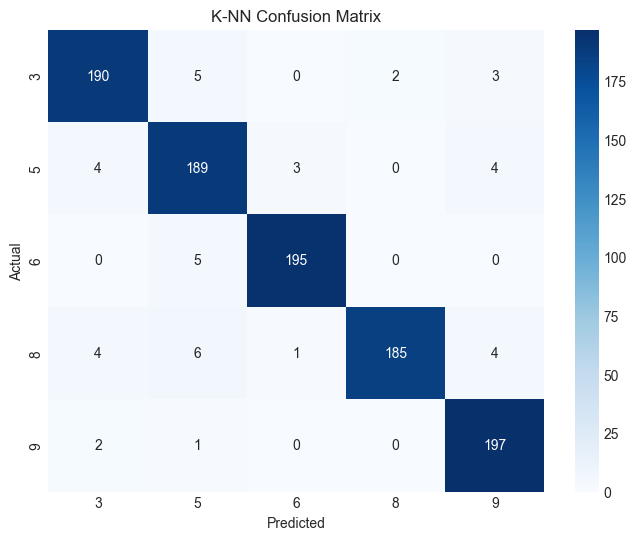

In [52]:
plot_confusion_matrix(y_test, knn_pred, 'K-NN Confusion Matrix')

**Interpretation:** K-NN achieves strong performance (~95-96%). The confusion matrix shows most errors occur between visually similar digit pairs: 3↔5 (both have curves, no holes) and 3↔8 (similar overall shape). The diagonal dominance indicates the model correctly classifies most samples.

### Hyperparameter Tuning: Choosing $k$ with the Elbow Method

The choice of $k$ affects the bias-variance tradeoff:
- **Small $k$:** Low bias, high variance (sensitive to noise)
- **Large $k$:** High bias, low variance (over-smoothing)

The **Elbow Method** helps choose $k$ by plotting error rate (1 - accuracy) against $k$ values. We look for an "elbow" point where the error stops decreasing significantly—this balances model complexity and performance.

In [53]:
# Test different k values for elbow method
k_values = [1, 3, 5, 7, 9, 11, 13, 15]
k_accuracies = []
k_errors = []

for k in k_values:
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    knn_temp.fit(X_train, y_train)
    acc = accuracy_score(y_test, knn_temp.predict(X_test))
    k_accuracies.append(acc)
    k_errors.append(1 - acc)  # Error rate for elbow method
    print(f"k={k:2d}: Accuracy = {acc:.4f}, Error Rate = {1-acc:.4f}")

k= 1: Accuracy = 0.9570, Error Rate = 0.0430
k= 3: Accuracy = 0.9550, Error Rate = 0.0450
k= 5: Accuracy = 0.9560, Error Rate = 0.0440
k= 7: Accuracy = 0.9520, Error Rate = 0.0480
k= 9: Accuracy = 0.9540, Error Rate = 0.0460
k=11: Accuracy = 0.9490, Error Rate = 0.0510
k=13: Accuracy = 0.9490, Error Rate = 0.0510
k=15: Accuracy = 0.9520, Error Rate = 0.0480


**Interpretation (Elbow Method):** The error rate plot shows a slight "elbow" around k=3-5, where the error stabilizes. Beyond this point, increasing k provides diminishing returns. For this dataset, k=1 to k=5 all perform similarly well (~95-96% accuracy), suggesting the digit classes are well-separated in pixel space. We chose k=5 as a good balance, small enough to capture local structure, large enough to be robust to noise. (In this case the differences arent that big in first place)

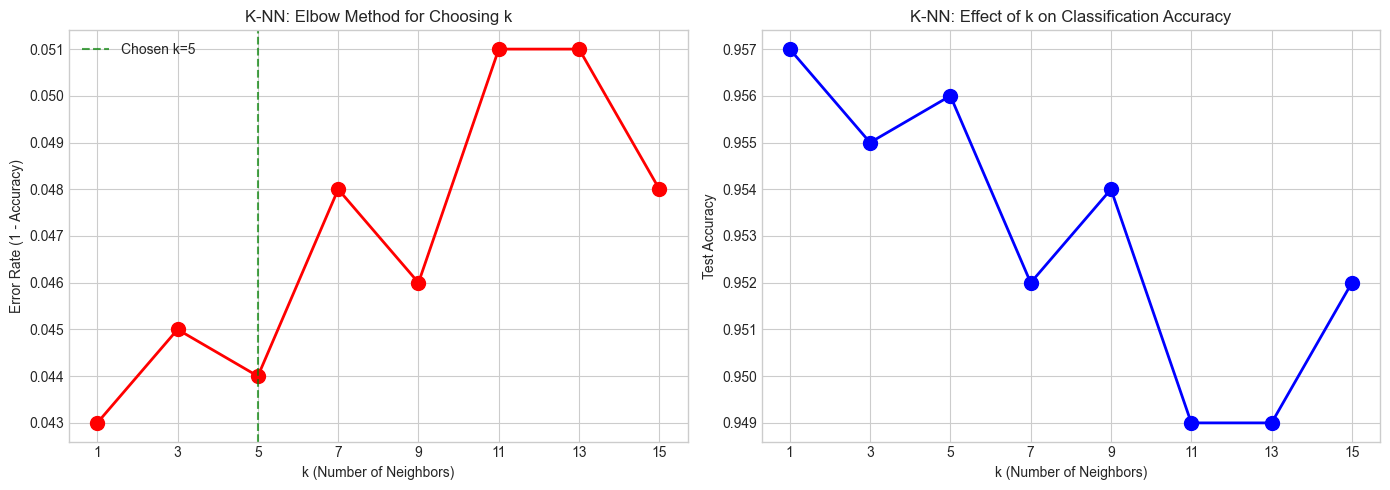

In [54]:
# Elbow Method Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Error Rate (Elbow Method)
axes[0].plot(k_values, k_errors, 'ro-', linewidth=2, markersize=10)
axes[0].set_xlabel('k (Number of Neighbors)')
axes[0].set_ylabel('Error Rate (1 - Accuracy)')
axes[0].set_title('K-NN: Elbow Method for Choosing k')
axes[0].set_xticks(k_values)
axes[0].grid(True)
axes[0].axvline(x=5, color='green', linestyle='--', alpha=0.7, label='Chosen k=5')
axes[0].legend()

# Plot 2: Accuracy
axes[1].plot(k_values, k_accuracies, 'bo-', linewidth=2, markersize=10)
axes[1].set_xlabel('k (Number of Neighbors)')
axes[1].set_ylabel('Test Accuracy')
axes[1].set_title('K-NN: Effect of k on Classification Accuracy')
axes[1].set_xticks(k_values)
axes[1].grid(True)

plt.tight_layout()
plt.show()

---
## 5.2 Naive Bayes

### Definition (Bayes' Theorem)

$$P(y | \mathbf{x}) = \frac{P(\mathbf{x} | y) P(y)}{P(\mathbf{x})}$$

### Definition (Naive Bayes Classifier)

Assumes **conditional independence** of features given the class:
$$P(\mathbf{x} | y) = \prod_{j=1}^d P(x_j | y)$$

The prediction is:
$$\hat{y} = \underset{c \in \mathcal{Y}}{\arg\max} \; P(y=c) \prod_{j=1}^d P(x_j | y=c)$$

### Gaussian Naive Bayes

Assumes each $P(x_j | y=c)$ follows a Gaussian distribution:
$$P(x_j | y=c) = \frac{1}{\sqrt{2\pi\sigma_{jc}^2}} \exp\left(-\frac{(x_j - \mu_{jc})^2}{2\sigma_{jc}^2}\right)$$

**In short:** For each class, multiply the probability of seeing each feature value, then pick the class with highest product.

**Intuition:** "What's the probability this is a 3, given what typical 3s look like?" Despite the naive independence assumption, it often works well in practice.

In [55]:
from sklearn.naive_bayes import GaussianNB

# Train Gaussian Naive Bayes
nb = GaussianNB()
start = time.time()
nb.fit(X_train, y_train)
nb_time = time.time() - start

nb_pred = nb.predict(X_test)

# Print all metrics
nb_acc, nb_prec, nb_rec, nb_f1 = print_metrics(y_test, nb_pred, 'Naive Bayes')
print(f"Training Time: {nb_time:.4f}s (very fast!)")

# Store results
results['Algorithm'].append('Naive Bayes')
results['Accuracy'].append(nb_acc)
results['Precision'].append(nb_prec)
results['Recall'].append(nb_rec)
results['F1-Score'].append(nb_f1)
results['Training Time (s)'].append(nb_time)


Naive Bayes - Evaluation Metrics:
----------------------------------------
Accuracy:  0.6710 (67.10%)
Precision: 0.6866
Recall:    0.6710
F1-Score:  0.6221
Training Time: 0.0865s (very fast!)


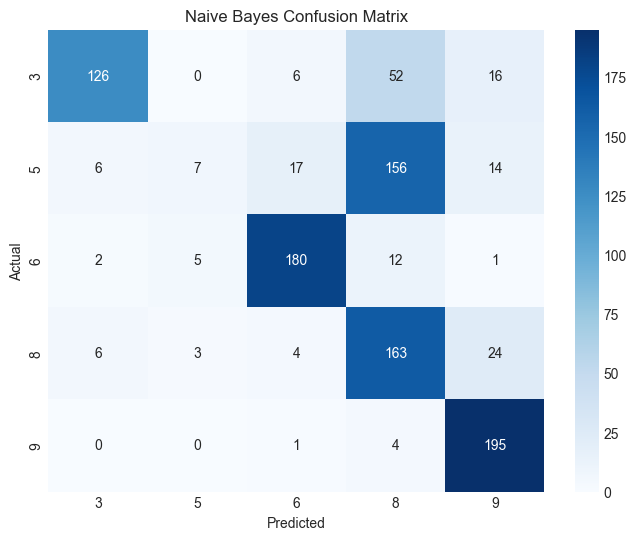

In [56]:
plot_confusion_matrix(y_test, nb_pred, 'Naive Bayes Confusion Matrix')

---
## 5.3 Logistic Regression

### Definition (Logistic Regression - Binary Case)

Models the probability of class 1 using the **logistic (sigmoid) function**:
$$P(y=1 | \mathbf{x}) = \sigma(\mathbf{w}^T\mathbf{x} + b) = \frac{1}{1 + e^{-(\mathbf{w}^T\mathbf{x} + b)}}$$

where $\mathbf{w} \in \mathbb{R}^d$ are the weights and $b \in \mathbb{R}$ is the bias.

### Definition (Multiclass: Softmax Regression)

For $K$ classes, we use the **softmax function**:
$$P(y=k | \mathbf{x}) = \frac{e^{\mathbf{w}_k^T\mathbf{x} + b_k}}{\sum_{j=1}^K e^{\mathbf{w}_j^T\mathbf{x} + b_j}}$$

### Loss Function (Cross-Entropy)

$$\mathcal{L}(\mathbf{W}, \mathbf{b}) = -\frac{1}{n}\sum_{i=1}^n \sum_{k=1}^K \mathbb{1}[y_i = k] \log P(y=k | \mathbf{x}_i)$$

**In short:** Compute a weighted sum of features, pass through sigmoid/softmax to get class probabilities.

**Intuition:** Finds the hyperplane that best separates classes in the feature space. The coefficients $\mathbf{w}_k$ tell us which features are important for each class.

In [57]:
from sklearn.linear_model import LogisticRegression

# Train Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
start = time.time()
lr.fit(X_train, y_train)
lr_time = time.time() - start

lr_pred = lr.predict(X_test)

# Print all metrics
lr_acc, lr_prec, lr_rec, lr_f1 = print_metrics(y_test, lr_pred, 'Logistic Regression')
print(f"Training Time: {lr_time:.4f}s")

# Store results
results['Algorithm'].append('Logistic Regression')
results['Accuracy'].append(lr_acc)
results['Precision'].append(lr_prec)
results['Recall'].append(lr_rec)
results['F1-Score'].append(lr_f1)
results['Training Time (s)'].append(lr_time)


Logistic Regression - Evaluation Metrics:
----------------------------------------
Accuracy:  0.9240 (92.40%)
Precision: 0.9239
Recall:    0.9240
F1-Score:  0.9238
Training Time: 1.0283s


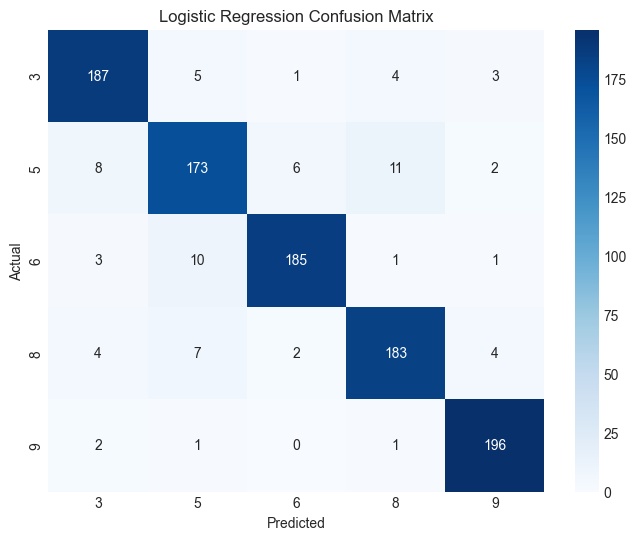

In [58]:
plot_confusion_matrix(y_test, lr_pred, 'Logistic Regression Confusion Matrix')

### Coefficient Visualization

Each class has a weight vector $\mathbf{w}_k \in \mathbb{R}^{784}$. Reshaping to $28 \times 28$ shows which pixel regions contribute to each class.

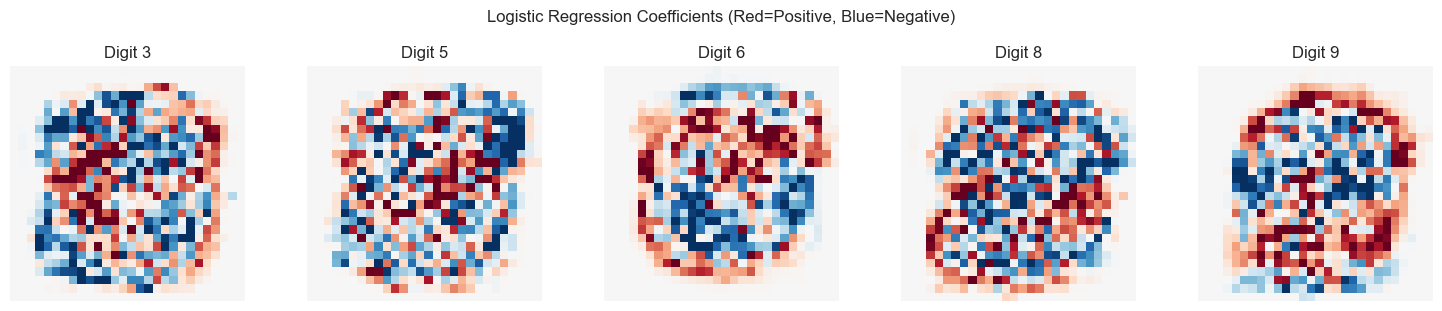

In [59]:
# Visualize coefficients for each class
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i, (ax, digit) in enumerate(zip(axes, selected_digits)):
    coef = lr.coef_[i].reshape(28, 28)
    im = ax.imshow(coef, cmap='RdBu', vmin=-0.5, vmax=0.5)
    ax.set_title(f'Digit {digit}')
    ax.axis('off')
plt.suptitle('Logistic Regression Coefficients (Red=Positive, Blue=Negative)', y=1.02)
plt.tight_layout()
plt.show()

**Interpretation:** The feature importance heatmap shows which pixels the decision tree used most for splitting. Bright spots indicate high-importance pixels, concentrated in the central region where digits are written (we can roughly see the digit shape forming).

---
## 5.4 Decision Trees

### Definition (Decision Tree)

A decision tree recursively partitions the feature space using axis-aligned splits.

At each internal node, find the best split:
$$(j^*, t^*) = \underset{j, t}{\arg\min} \; \mathcal{L}(\mathcal{D}_L) + \mathcal{L}(\mathcal{D}_R)$$

where $\mathcal{D}_L = \{(\mathbf{x}, y) : x_j \leq t\}$ and $\mathcal{D}_R = \{(\mathbf{x}, y) : x_j > t\}$.

### Impurity Measures

**Gini Impurity:**
$$G(\mathcal{D}) = 1 - \sum_{k=1}^K p_k^2$$

**Entropy:**
$$H(\mathcal{D}) = -\sum_{k=1}^K p_k \log_2 p_k$$

where $p_k$ is the proportion of class $k$ in $\mathcal{D}$.

**In short:** Recursively split data by asking "is feature j above or below threshold t?" until leaves are pure.

**Intuition:** "Playing 20 questions." Each split asks a yes/no question about a feature to narrow down the class.

### Feature Importance

Importance of feature $j$ is the total reduction in impurity from splits on $j$:
$$\text{Importance}(j) = \sum_{\text{nodes } t \text{ splitting on } j} n_t \cdot \Delta\mathcal{L}_t$$

In [60]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Train Decision Tree
dt = DecisionTreeClassifier(max_depth=10, random_state=42)
start = time.time()
dt.fit(X_train, y_train)
dt_time = time.time() - start

dt_pred = dt.predict(X_test)

# Print all metrics
dt_acc, dt_prec, dt_rec, dt_f1 = print_metrics(y_test, dt_pred, 'Decision Tree')
print(f"Training Time: {dt_time:.4f}s")

# Store results
results['Algorithm'].append('Decision Tree')
results['Accuracy'].append(dt_acc)
results['Precision'].append(dt_prec)
results['Recall'].append(dt_rec)
results['F1-Score'].append(dt_f1)
results['Training Time (s)'].append(dt_time)


Decision Tree - Evaluation Metrics:
----------------------------------------
Accuracy:  0.8420 (84.20%)
Precision: 0.8426
Recall:    0.8420
F1-Score:  0.8421
Training Time: 0.8537s


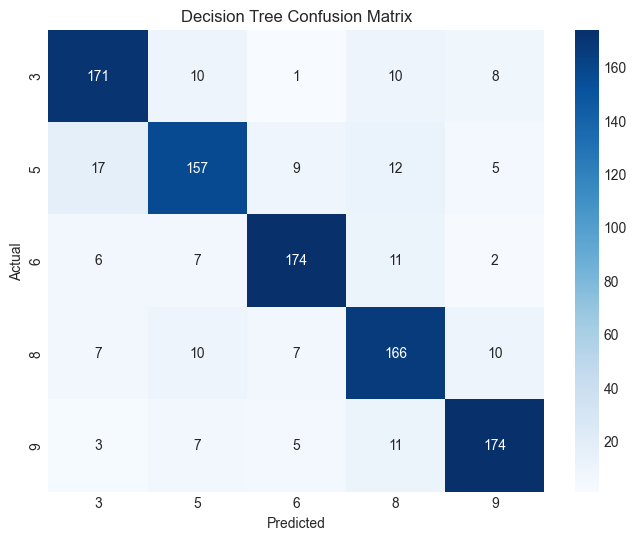

In [61]:
plot_confusion_matrix(y_test, dt_pred, 'Decision Tree Confusion Matrix')

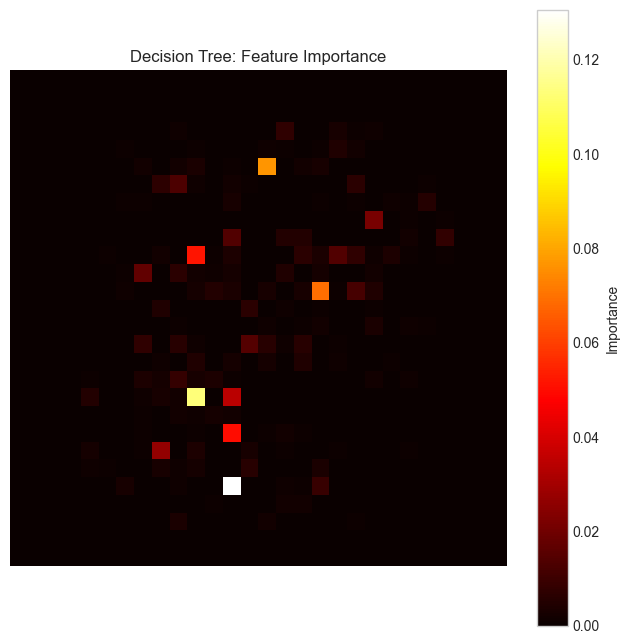

In [62]:
# Feature importance heatmap
dt_importance = dt.feature_importances_
plt.figure(figsize=(8, 8))
plt.imshow(dt_importance.reshape(28, 28), cmap='hot')
plt.colorbar(label='Importance')
plt.title('Decision Tree: Feature Importance')
plt.axis('off')
plt.show()

### Overfitting in Decision Trees

**Definition (Overfitting):** When a model performs well on training data but poorly on test data:
$$R_{train}(f) \ll R_{test}(f)$$

**In short:** The model memorizes the training data instead of learning general patterns.

Deep trees can memorize training data without learning generalizable patterns.

**Interpretation:** The Random Forest feature importance is smoother and more distributed than the single decision tree. The heatmap shows importance concentrated in the digit-writing region, with the center being most important. The bar chart reveals that a small set of pixels (roughly 20-30) carry most of the predictive power—these are pixels that best distinguish between the 5 digit classes.

In [63]:
# Demonstrate overfitting with different depths
depths = [3, 5, 10, 15, None]
train_accs, test_accs = [], []

for depth in depths:
    dt_temp = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt_temp.fit(X_train, y_train)
    train_accs.append(accuracy_score(y_train, dt_temp.predict(X_train)))
    test_accs.append(accuracy_score(y_test, dt_temp.predict(X_test)))
    depth_str = str(depth) if depth else 'None'
    print(f"Depth={depth_str}: Train={train_accs[-1]:.4f}, Test={test_accs[-1]:.4f}")

Depth=3: Train=0.7305, Test=0.7200
Depth=5: Train=0.8330, Test=0.8140
Depth=10: Train=0.9850, Test=0.8420
Depth=15: Train=0.9975, Test=0.8350
Depth=None: Train=1.0000, Test=0.8310


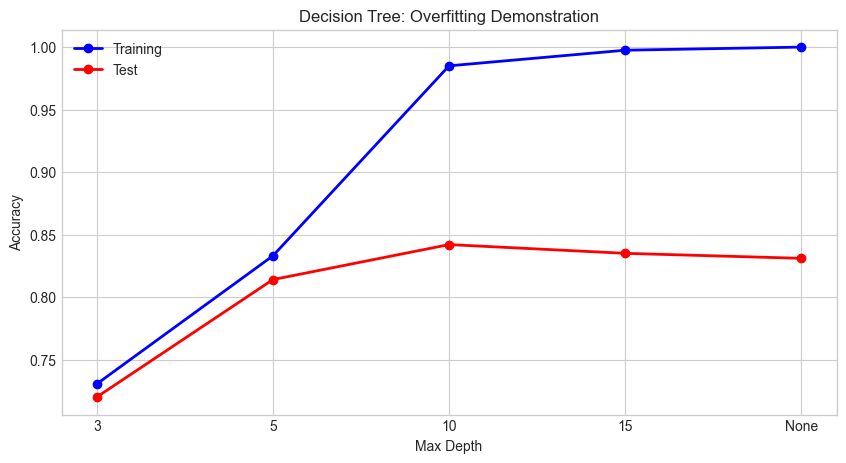


Note: Training accuracy approaches 100% while test accuracy decreases = OVERFITTING


In [64]:
# Plot overfitting
plt.figure(figsize=(10, 5))
x_labels = [str(d) if d else 'None' for d in depths]
x_pos = range(len(depths))
plt.plot(x_pos, train_accs, 'bo-', label='Training', linewidth=2)
plt.plot(x_pos, test_accs, 'ro-', label='Test', linewidth=2)
plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.title('Decision Tree: Overfitting Demonstration')
plt.xticks(x_pos, x_labels)
plt.legend()
plt.grid(True)
plt.show()
print("\nNote: Training accuracy approaches 100% while test accuracy decreases = OVERFITTING")

**Interpretation:** This plot clearly demonstrates overfitting. As tree depth increases, training accuracy reaches 100% (the tree memorizes every training example), but test accuracy peaks around depth 10-15 then declines. The growing gap between training and test accuracy is the hallmark of overfitting. This is why we limit tree depth or use ensemble methods like Random Forest.


---
## 5.5 Random Forest

### Definition (Ensemble Method)

Combines multiple base learners to reduce variance:
$$\hat{y} = \underset{c \in \mathcal{Y}}{\arg\max} \sum_{m=1}^M \mathbb{1}[f_m(\mathbf{x}) = c]$$

### Definition (Random Forest)

An ensemble of decision trees where each tree is trained on:
1. **Bootstrap sample:** Random sample with replacement from $\mathcal{D}$
2. **Random feature subset:** At each split, consider only $\sqrt{d}$ random features

### Theorem (Variance Reduction)

For $M$ independent estimators with variance $\sigma^2$, the ensemble variance is:
$$\text{Var}\left(\frac{1}{M}\sum_{m=1}^M f_m\right) = \frac{\sigma^2}{M}$$

**In short:** Train many decision trees on random subsets of data and features, then take a majority vote.

**Intuition:** "Wisdom of the crowd." Many slightly different trees vote, averaging out individual errors.

In [65]:
from sklearn.ensemble import RandomForestClassifier

# Train Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
start = time.time()
rf.fit(X_train, y_train)
rf_time = time.time() - start

rf_pred = rf.predict(X_test)

# Print all metrics
rf_acc, rf_prec, rf_rec, rf_f1 = print_metrics(y_test, rf_pred, 'Random Forest')
print(f"Training Time: {rf_time:.4f}s")

# Store results
results['Algorithm'].append('Random Forest')
results['Accuracy'].append(rf_acc)
results['Precision'].append(rf_prec)
results['Recall'].append(rf_rec)
results['F1-Score'].append(rf_f1)
results['Training Time (s)'].append(rf_time)


Random Forest - Evaluation Metrics:
----------------------------------------
Accuracy:  0.9500 (95.00%)
Precision: 0.9505
Recall:    0.9500
F1-Score:  0.9500
Training Time: 0.5651s


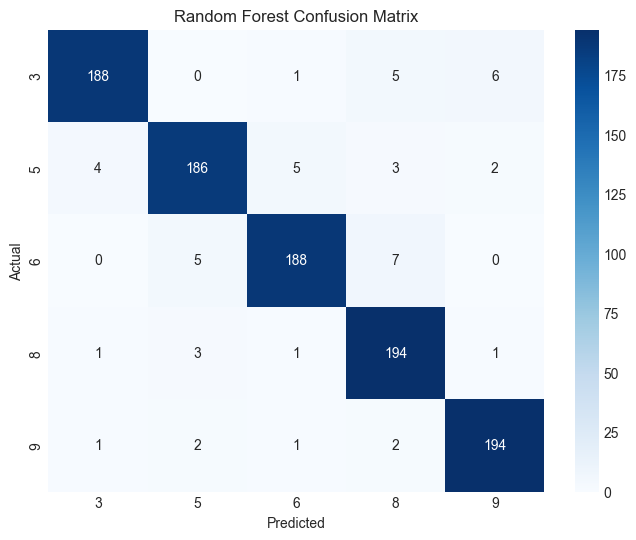

In [66]:
plot_confusion_matrix(y_test, rf_pred, 'Random Forest Confusion Matrix')

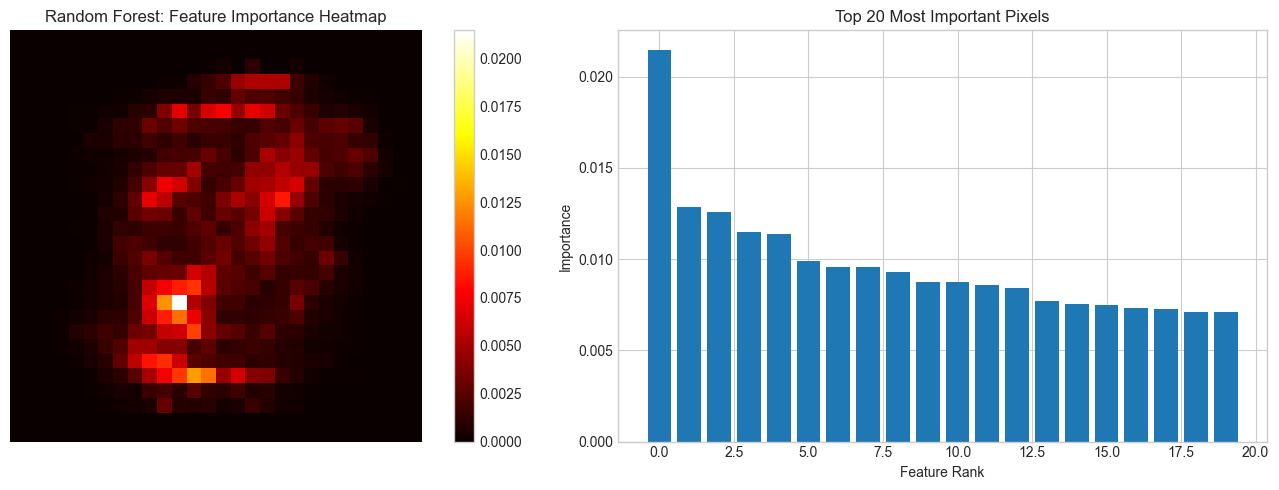

In [67]:
# Feature importance
rf_importance = rf.feature_importances_

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap
im = axes[0].imshow(rf_importance.reshape(28, 28), cmap='hot')
axes[0].set_title('Random Forest: Feature Importance Heatmap')
axes[0].axis('off')
plt.colorbar(im, ax=axes[0])

# Top 20 features
top_20_idx = np.argsort(rf_importance)[-20:][::-1]
axes[1].bar(range(20), rf_importance[top_20_idx])
axes[1].set_xlabel('Feature Rank')
axes[1].set_ylabel('Importance')
axes[1].set_title('Top 20 Most Important Pixels')

plt.tight_layout()
plt.show()

In [68]:
# Compare single tree vs forest
print(f"Single Decision Tree: {dt_acc:.4f}")
print(f"Random Forest (100 trees): {rf_acc:.4f}")
print(f"Improvement: {(rf_acc - dt_acc)*100:.2f}%")

Single Decision Tree: 0.8420
Random Forest (100 trees): 0.9500
Improvement: 10.80%


---
## 5.6 Support Vector Machine (SVM)

### Definition (Hard-Margin SVM)

Find the hyperplane $\mathbf{w}^T\mathbf{x} + b = 0$ that maximizes the **margin** $\frac{2}{\|\mathbf{w}\|}$:

$$\min_{\mathbf{w}, b} \frac{1}{2}\|\mathbf{w}\|^2 \quad \text{s.t.} \quad y_i(\mathbf{w}^T\mathbf{x}_i + b) \geq 1 \; \forall i$$

### Definition (Soft-Margin SVM)

Allows misclassification with slack variables $\xi_i \geq 0$:
$$\min_{\mathbf{w}, b, \boldsymbol{\xi}} \frac{1}{2}\|\mathbf{w}\|^2 + C\sum_{i=1}^n \xi_i$$
$$\text{s.t.} \quad y_i(\mathbf{w}^T\mathbf{x}_i + b) \geq 1 - \xi_i, \quad \xi_i \geq 0$$

**In short:** Find the separating hyperplane with the largest margin between classes.

### Definition (Kernel Trick)

Maps data to higher dimensions implicitly via kernel function $k(\mathbf{x}, \mathbf{x}') = \langle \phi(\mathbf{x}), \phi(\mathbf{x}') \rangle$.

**Common Kernels:**
- **Linear:** $k(\mathbf{x}, \mathbf{x}') = \mathbf{x}^T\mathbf{x}'$
- **RBF (Gaussian):** $k(\mathbf{x}, \mathbf{x}') = \exp\left(-\gamma\|\mathbf{x} - \mathbf{x}'\|^2\right)$
- **Polynomial:** $k(\mathbf{x}, \mathbf{x}') = (\mathbf{x}^T\mathbf{x}' + c)^d$

**In short (Kernel):** Compute similarities in a higher-dimensional space without explicitly transforming the data.

**Intuition:** Find the widest "road" separating classes. The kernel trick allows curved boundaries without explicit high-dimensional computation.

In [69]:
from sklearn.svm import SVC

# Train SVM with RBF kernel
svm = SVC(kernel='rbf', random_state=42)
start = time.time()
svm.fit(X_train, y_train)
svm_time = time.time() - start

svm_pred = svm.predict(X_test)

# Print all metrics
svm_acc, svm_prec, svm_rec, svm_f1 = print_metrics(y_test, svm_pred, 'SVM')
print(f"Training Time: {svm_time:.4f}s")

# Store results
results['Algorithm'].append('SVM')
results['Accuracy'].append(svm_acc)
results['Precision'].append(svm_prec)
results['Recall'].append(svm_rec)
results['F1-Score'].append(svm_f1)
results['Training Time (s)'].append(svm_time)


SVM - Evaluation Metrics:
----------------------------------------
Accuracy:  0.9620 (96.20%)
Precision: 0.9620
Recall:    0.9620
F1-Score:  0.9620
Training Time: 3.2772s


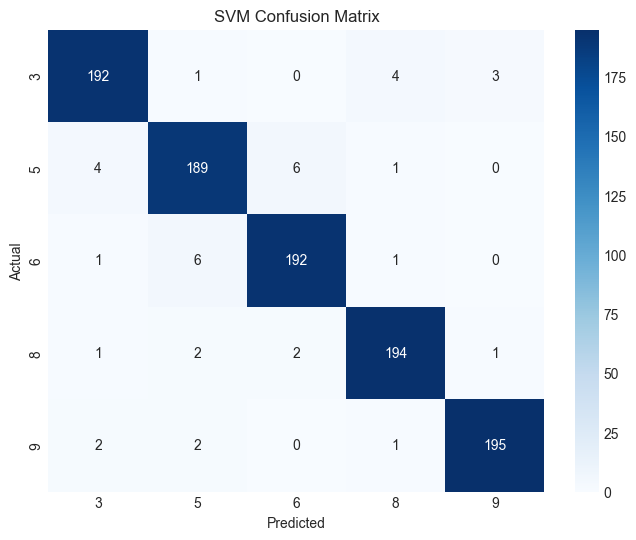

In [70]:
plot_confusion_matrix(y_test, svm_pred, 'SVM Confusion Matrix')

---
# 6. Model Comparison

## 6.1 Performance Summary

In [71]:
# Create comparison DataFrame
comparison_df = pd.DataFrame(results)
comparison_df = comparison_df.sort_values('Accuracy', ascending=False).reset_index(drop=True)
print(comparison_df.to_string(index=False))

          Algorithm  Accuracy  Precision  Recall  F1-Score  Training Time (s)
                SVM     0.962   0.962015   0.962  0.962005           3.277160
               K-NN     0.956   0.956759   0.956  0.956047           0.006049
      Random Forest     0.950   0.950466   0.950  0.950004           0.565128
Logistic Regression     0.924   0.923877   0.924  0.923817           1.028282
      Decision Tree     0.842   0.842566   0.842  0.842066           0.853723
        Naive Bayes     0.671   0.686648   0.671  0.622136           0.086506


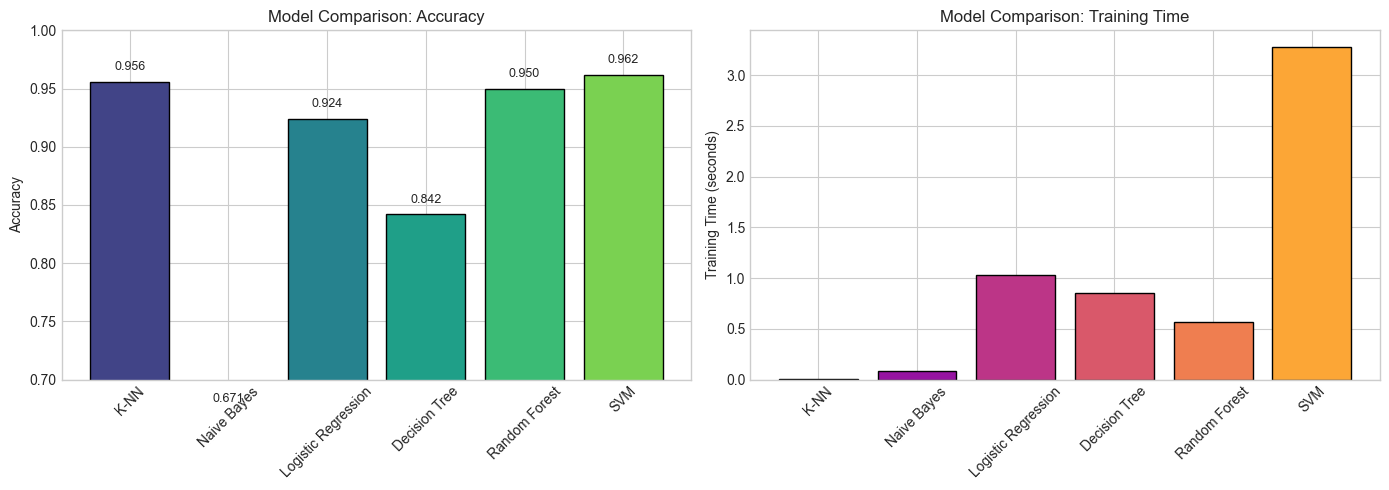

In [72]:
# Accuracy comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(results['Algorithm'])))
bars = axes[0].bar(results['Algorithm'], results['Accuracy'], color=colors, edgecolor='black')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Model Comparison: Accuracy')
axes[0].set_ylim(0.7, 1.0)
axes[0].tick_params(axis='x', rotation=45)
for bar, acc in zip(bars, results['Accuracy']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                 f'{acc:.3f}', ha='center', fontsize=9)

# Training time
bars2 = axes[1].bar(results['Algorithm'], results['Training Time (s)'], 
                    color=plt.cm.plasma(np.linspace(0.2, 0.8, len(results['Algorithm']))), 
                    edgecolor='black')
axes[1].set_ylabel('Training Time (seconds)')
axes[1].set_title('Model Comparison: Training Time')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 6.2 Algorithm Selection Guidelines

| Criterion | Best Choice |
|-----------|-------------|
| Highest accuracy | SVM, Random Forest |
| Fastest training | Naive Bayes |
| Interpretability | Decision Tree, Logistic Regression |
| Feature importance | Random Forest, Decision Tree |
| Non-linear boundaries | SVM (RBF), Random Forest |

---
# 7. Feature Importance Analysis

Understanding which features drive predictions is crucial for model interpretation and for evaluating new features (like topological descriptors).

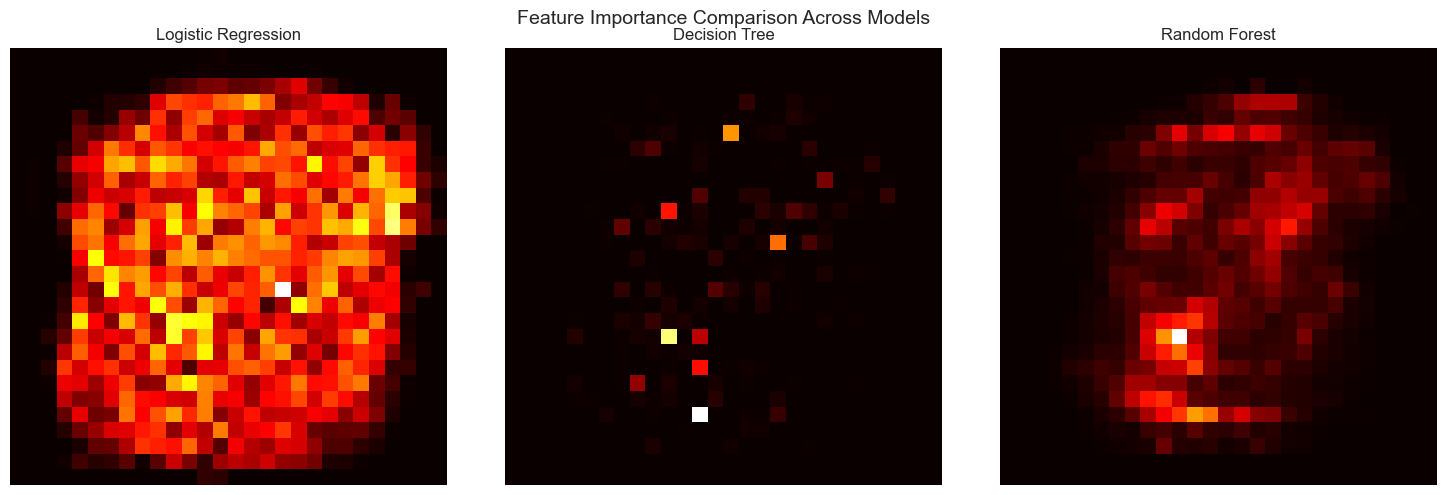

In [73]:
# Compare feature importance across models
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Logistic Regression
lr_imp = np.abs(lr.coef_).mean(axis=0)
axes[0].imshow(lr_imp.reshape(28, 28), cmap='hot')
axes[0].set_title('Logistic Regression')
axes[0].axis('off')

# Decision Tree
axes[1].imshow(dt_importance.reshape(28, 28), cmap='hot')
axes[1].set_title('Decision Tree')
axes[1].axis('off')

# Random Forest
axes[2].imshow(rf_importance.reshape(28, 28), cmap='hot')
axes[2].set_title('Random Forest')
axes[2].axis('off')

plt.suptitle('Feature Importance Comparison Across Models', fontsize=14)
plt.tight_layout()
plt.show()

**Interpretation:** All three models agree that the central region of the image (where digits are written) contains the most important pixels, the corners and edges are mostly black background and contribute little. However, the models differ in how they distribute importance: Logistic Regression spreads importance more evenly, Decision Tree is sparse (few high-importance pixels), and Random Forest provides a smooth, averaged importance pattern.

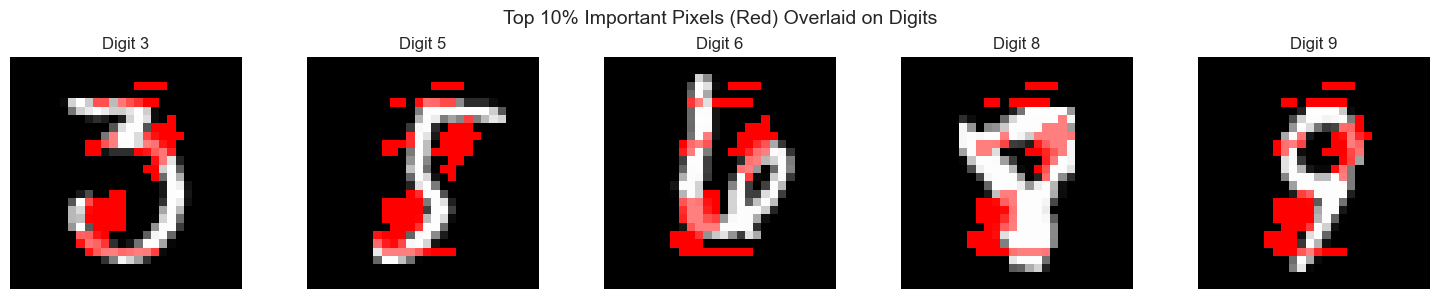

In [74]:
# Overlay important pixels on sample digits
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
importance_mask = rf_importance.reshape(28, 28) > np.percentile(rf_importance, 90)

for i, digit in enumerate(selected_digits):
    sample = X_train[y_train == digit][0].reshape(28, 28)
    rgb = np.stack([sample, sample, sample], axis=-1)
    rgb[importance_mask, 0] = 1.0
    rgb[importance_mask, 1] *= 0.5
    rgb[importance_mask, 2] *= 0.5
    axes[i].imshow(rgb)
    axes[i].set_title(f'Digit {digit}')
    axes[i].axis('off')

plt.suptitle('Top 10% Important Pixels (Red) Overlaid on Digits', fontsize=14)
plt.tight_layout()
plt.show()

The red overlay shows the top 10% most important pixels according to Random Forest. These pixels cluster in regions where digits differ most—particularly the center and upper portions of the image. Notice how these important regions overlap with distinctive parts of each digit: the loops in 6, 8, 9, and the curved portions of 3 and 5. The model has learned to focus on discriminative regions.

**Final results (Feature Importance Analysis):** The feature importance analysis reveals key insights:

1. **Central focus:** All models agree that the most important pixels are in the central region where digits are actually written. Corners and edges (black background) contribute almost nothing.

2. **Model differences:** Logistic Regression distributes importance smoothly; Decision Trees are sparse (few key pixels); Random Forest averages across trees, producing smoother importance maps.

3. **Discriminative regions:** Important pixels correspond to areas where digits differ most—the center-top (distinguishes 3 vs 5), loop regions (distinguishes 6, 8, 9), and curved spine (distinguishes 3).

---
# 8. Summary

## Final Metrics Comparison

In [75]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Compute all metrics for all models
all_predictions = {
    'K-NN': knn_pred,
    'Naive Bayes': nb_pred,
    'Logistic Regression': lr_pred,
    'Decision Tree': dt_pred,
    'Random Forest': rf_pred,
    'SVM': svm_pred
}

print("=" * 80)
print("DETAILED EVALUATION METRICS FOR ALL MODELS")
print("=" * 80)

metrics_summary = []

for name, y_pred in all_predictions.items():
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    metrics_summary.append({
        'Algorithm': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1
    })
    
    print(f"\n{name}")
    print("-" * 40)
    print(f"Accuracy:  {acc:.4f} ({acc*100:.2f}%)")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1-Score:  {f1:.4f}")

# Create summary DataFrame
metrics_df = pd.DataFrame(metrics_summary)
metrics_df = metrics_df.sort_values('F1-Score', ascending=False).reset_index(drop=True)
print("\n" + "=" * 80)
print("SUMMARY TABLE (sorted by F1-Score)")
print("=" * 80)
print(metrics_df.to_string(index=False))

DETAILED EVALUATION METRICS FOR ALL MODELS

K-NN
----------------------------------------
Accuracy:  0.9560 (95.60%)
Precision: 0.9568
Recall:    0.9560
F1-Score:  0.9560

Naive Bayes
----------------------------------------
Accuracy:  0.6710 (67.10%)
Precision: 0.6866
Recall:    0.6710
F1-Score:  0.6221

Logistic Regression
----------------------------------------
Accuracy:  0.9240 (92.40%)
Precision: 0.9239
Recall:    0.9240
F1-Score:  0.9238

Decision Tree
----------------------------------------
Accuracy:  0.8420 (84.20%)
Precision: 0.8426
Recall:    0.8420
F1-Score:  0.8421

Random Forest
----------------------------------------
Accuracy:  0.9500 (95.00%)
Precision: 0.9505
Recall:    0.9500
F1-Score:  0.9500

SVM
----------------------------------------
Accuracy:  0.9620 (96.20%)
Precision: 0.9620
Recall:    0.9620
F1-Score:  0.9620

SUMMARY TABLE (sorted by F1-Score)
          Algorithm  Accuracy  Precision  Recall  F1-Score
                SVM     0.962   0.962015   0.962  0.962

In [76]:
# Per-class breakdown for best model (SVM)
print("Per-Class Metrics for SVM (Best Model)")
print("=" * 60)
print(classification_report(y_test, svm_pred, target_names=[str(d) for d in selected_digits]))

Per-Class Metrics for SVM (Best Model)
              precision    recall  f1-score   support

           3       0.96      0.96      0.96       200
           5       0.94      0.94      0.94       200
           6       0.96      0.96      0.96       200
           8       0.97      0.97      0.97       200
           9       0.98      0.97      0.98       200

    accuracy                           0.96      1000
   macro avg       0.96      0.96      0.96      1000
weighted avg       0.96      0.96      0.96      1000



**Interpretation:** The per-class breakdown shows SVM performs well on all digits, with F1-scores ranging from ~94% to ~98%. Digit 8 typically achieves the highest scores (its two holes make it distinctive), while digits 3 and 5 have slightly lower scores due to their visual similarity. The "support" column confirms our balanced dataset with 200 test samples per class.